# Вторая лабораторная работа: multi-task

## Импорты и константы

In [124]:
import gc
import random
import warnings
from datetime import datetime
from pathlib import Path
from pprint import pp

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [125]:
AUDIO_DATASET = Path("data/MELD_audio/archive/dev")
METADATA = Path("data/MELD_audio/dev.csv")

In [126]:
FRIENDS_NAMES = ['Phoebe', 'Monica', 'Ross', 'Chandler', 'Joey', 'Rachel']

In [127]:
metadata_df = pd.read_csv(METADATA, index_col="Sr No.")
# Ограничиваем только 6 главными героями
metadata_df = metadata_df[metadata_df["Speaker"].isin(FRIENDS_NAMES)]

In [128]:
metadata_df.head()

,Utterance,Speaker,Emotion,Sentiment,Dialogue_ID,Utterance_ID,Season,Episode,StartTime,EndTime
Sr No.,,,,,,,,,,
1,"Oh my God, hes lost it. Hes totally lost it.",Phoebe,sadness,negative,0,0,4,7,"00:20:57,256","00:21:00,049"
2,What?,Monica,surprise,negative,0,1,4,7,"00:21:01,927","00:21:03,261"
3,"Or! Or, we could go to the bank, close our acc...",Ross,neutral,neutral,1,0,4,4,"00:12:24,660","00:12:30,915"
4,Youre a genius!,Chandler,joy,positive,1,1,4,4,"00:12:32,334","00:12:33,960"
5,"Aww, man, now we wont be bank buddies!",Joey,sadness,negative,1,2,4,4,"00:12:34,211","00:12:37,505"


In [129]:
color_palette = dict.fromkeys([
    "maroon",
    "saddlebrown",
    "darkolivegreen",
    "olive",
    "burlywood",
    "antiquewhite",
], 0)

In [130]:
def choose_color(colors, first_n=2):
    color_n = sorted(colors, key=colors.get)[:first_n]
    color = random.choice(color_n)
    colors[color] += 1
    return color

In [131]:
PLT_FIG_SIZE = (12,6)

In [132]:
SR = 16000

In [147]:
EMBEDDINGS_PATH = Path("data/embeddings")
EMBEDDINGS_PATH.mkdir(exist_ok=True)

## Чистим метадату

In [133]:
def join_dialogue_utterance(dialogue_id, utterance_id):
    return f"dia{dialogue_id}_utt{utterance_id}.flac"


audio_names = []
for row in metadata_df.iterrows():
    values = row[1]
    audio_name = join_dialogue_utterance(
        values["Dialogue_ID"], values["Utterance_ID"]
    )
    if Path(AUDIO_DATASET / audio_name).exists():
        audio_names.append(AUDIO_DATASET / audio_name)
    else:
        audio_names.append(np.nan)

metadata_df["audio_path"] = audio_names
metadata_df = metadata_df.dropna()

In [134]:
metadata_df

,Utterance,Speaker,Emotion,Sentiment,Dialogue_ID,Utterance_ID,Season,Episode,StartTime,EndTime,audio_path
Sr No.,,,,,,,,,,,
1,"Oh my God, hes lost it. Hes totally lost it.",Phoebe,sadness,negative,0,0,4,7,"00:20:57,256","00:21:00,049",data/MELD_audio/archive/dev/dia0_utt0.flac
2,What?,Monica,surprise,negative,0,1,4,7,"00:21:01,927","00:21:03,261",data/MELD_audio/archive/dev/dia0_utt1.flac
3,"Or! Or, we could go to the bank, close our acc...",Ross,neutral,neutral,1,0,4,4,"00:12:24,660","00:12:30,915",data/MELD_audio/archive/dev/dia1_utt0.flac
4,Youre a genius!,Chandler,joy,positive,1,1,4,4,"00:12:32,334","00:12:33,960",data/MELD_audio/archive/dev/dia1_utt1.flac
5,"Aww, man, now we wont be bank buddies!",Joey,sadness,negative,1,2,4,4,"00:12:34,211","00:12:37,505",data/MELD_audio/archive/dev/dia1_utt2.flac
...,...,...,...,...,...,...,...,...,...,...,...
1174,No.,Monica,sadness,negative,113,9,6,2,"00:19:28,792","00:19:29,876",data/MELD_audio/archive/dev/dia113_utt9.flac
1175,What? Oh my God! Im gonna miss you so much!,Rachel,sadness,negative,113,10,6,2,"00:19:33,213","00:19:35,965",data/MELD_audio/archive/dev/dia113_utt10.flac
1176,Im gonna miss you!,Monica,sadness,negative,113,11,6,2,"00:19:36,175","00:19:37,967",data/MELD_audio/archive/dev/dia113_utt11.flac


## EDA

In [135]:
print(f"Всего в датасете {len(metadata_df)} реплик")

Всего в датасете 952 реплик


In [136]:
speaker_utterances_amount = {}
for speaker in metadata_df["Speaker"].unique():
    speaker_utterances_amount[speaker] = [
        len(metadata_df[metadata_df["Speaker"] == speaker])
    ]

print("Реплик у каждого героя:")
pp(speaker_utterances_amount)

Реплик у каждого героя:
{'Phoebe': [184],
 'Monica': [137],
 'Ross': [217],
 'Chandler': [101],
 'Joey': [149],
 'Rachel': [164]}


In [137]:
unique_emotions = metadata_df["Emotion"].unique()
print(f"Всего в датасете {len(unique_emotions)} эмоций: {unique_emotions}")

Всего в датасете 7 эмоций: ['sadness' 'surprise' 'neutral' 'joy' 'anger' 'disgust' 'fear']


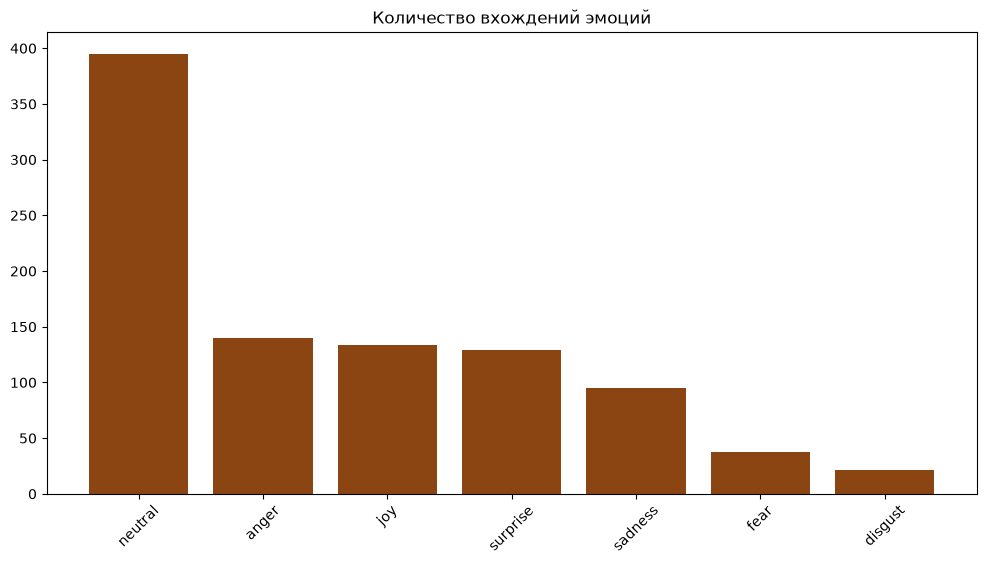

In [138]:
emotion_counts = metadata_df["Emotion"].value_counts()

plt.figure(figsize=PLT_FIG_SIZE)
plt.title("Количество вхождений эмоций")
plt.bar(
    emotion_counts.index,
    emotion_counts.to_numpy(dtype=int),
    color=choose_color(color_palette)
)
plt.xticks(rotation=45)
plt.show()

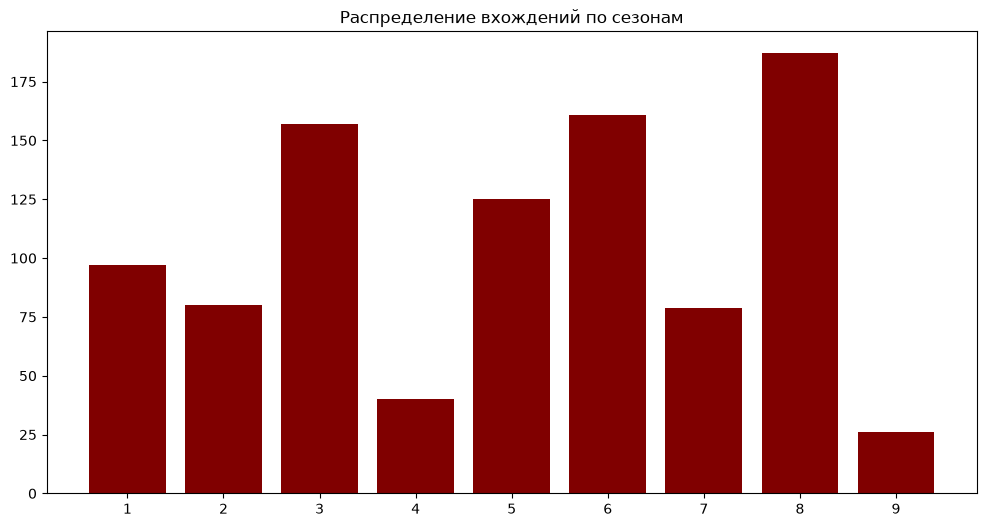

In [139]:
season_counts = metadata_df["Season"].value_counts()

plt.figure(figsize=PLT_FIG_SIZE)
plt.title("Распределение вхождений по сезонам")
plt.bar(
    season_counts.index,
    season_counts.to_numpy(dtype=int),
    color=choose_color(color_palette)
)
plt.xticks(season_counts.index)
plt.show()

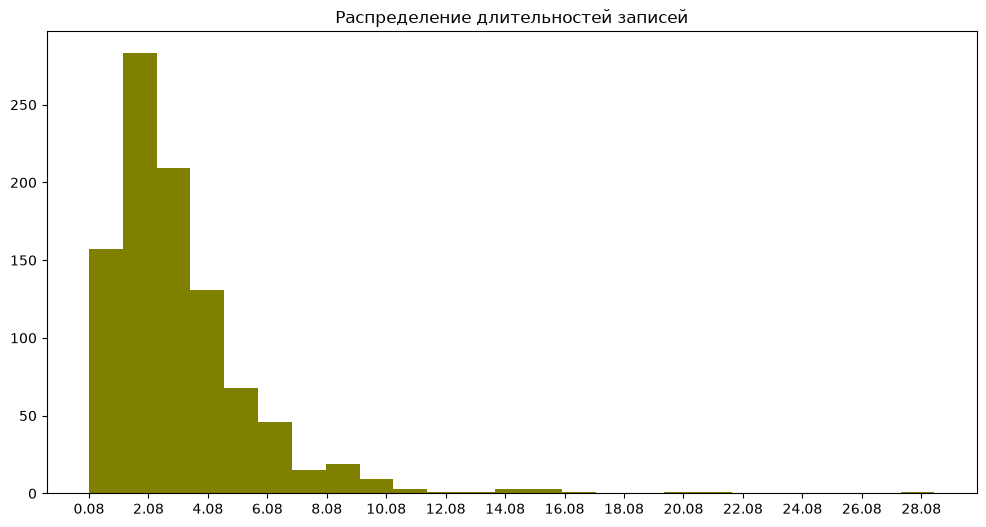

In [140]:
def str_to_dt(str_inpt):
    format = "%H:%M:%S,%f"
    datetime_str = datetime.strptime(str_inpt, format)  # noqa: DTZ007
    return datetime_str

utterance_start = metadata_df["StartTime"].apply(str_to_dt)
utterance_end = metadata_df["EndTime"].apply(str_to_dt)
utterance_dur = [
    x.total_seconds()
    for x in [
        end - start for start, end in zip(utterance_start, utterance_end)
    ]
]

plt.figure(figsize=PLT_FIG_SIZE)
plt.title("Распределение длительностей записей")
plt.hist(
    utterance_dur,
    color=choose_color(color_palette),
    bins=25
)
plt.xticks(np.arange(min(utterance_dur), max(utterance_dur), 2))
plt.show()

## Извлекаем признаки

In [ ]:
wav2vec2_embs_path = EMBEDDINGS_PATH / "wav2vec2.pt"

In [141]:
def extract_wav2vec2_embedding(
    audio_path,
    model_name="facebook/wav2vec2-base-960h",
    sr=SR,
):

    feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name)
    model = Wav2Vec2Model.from_pretrained(model_name).to(device)
    model.eval()


    # Загружаем mono-аудио и сразу ресемплируем в 16 kHz
    audio, _ = librosa.load(audio_path, sr=sr, mono=True)

    inputs = feature_extractor(
        audio,
        sampling_rate=sr,
        return_tensors="pt",
        padding=True,
    )

    input_values = inputs.input_values.to(device)

    with torch.inference_mode():
        outputs = model(input_values)

        # shape:
        # [batch, time, hidden_size]
        hidden_states = outputs.last_hidden_state

        # усредняем по времени
        embedding = hidden_states.mean(dim=1)

    # Переносим результат на CPU,
    # чтобы он не держал память CUDA
    embedding = embedding.squeeze(0).cpu()

    return embedding

In [ ]:
if not Path.exists(wav2vec2_embs_path):
    batch_size = 8
    wav2vec2_embs = []
    for idx in range(0, len(metadata_df), batch_size):
        batch_embs = extract_wav2vec2_embedding(metadata_df["audio_path"].iloc[idx : idx + batch_size].to_list())
        wav2vec2_embs.append(batch_embs)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    torch.save(wav2vec2_embs, EMBEDDINGS_PATH / "wav2vec2.pt")

else:
    wav2vec2_embs = torch.load(wav2vec2_embs_path)

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Cancellation requested; stopping current tasks.


KeyboardInterrupt: 

## Отдельно классифицируем персонажа

## Отдельно определяем сентимент

## Multi-task